In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from modules import SAB, ISAB, PMA
from models import DeepSet, SetTransformer, CondSM
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
from train_sm import train_val_test_loaders, MakeDataset
from pathlib import Path

import json

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/uni_cfg_samples_1e7/')

output_idx = 0
batch_size = 1024
num_batches = 400
train_size = 0.8
val_size = 0.1
test_size = 0.1

na = 200
radius = 150.0
R = np.sqrt(np.pi * radius ** 2 / na)
print(R)

voltages = []
configurations = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])
    configurations.append(batch['acc_xy'])    

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])

V = torch.from_numpy(np.concatenate(voltages)[:, [i for i in range(voltages[0].shape[1]) if i != output_idx]]).float()
X = torch.from_numpy(np.concatenate(configurations)).float()
y = torch.from_numpy(np.concatenate(currents)).float().unsqueeze(-1)

len_dataset = V.shape[0]

X = X * R / radius

dataset = TensorDataset(V, X, y)
generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")

18.799712059732506
train_set: 160000
val_set: 20000
test_set: 20000


In [4]:
def sort_by_radius(x):
    r2 = (x ** 2).sum(dim=-1)
    r2_sorted, idx = torch.sort(r2, dim=1)
    pts_sorted = torch.gather(
        x, 
        dim=1,
        index=idx.unsqueeze(-1).expand(-1, -1, 2)
    )

    return pts_sorted

"""
Model for coordinate representation 
"""
coord_h_dim = 90
coord_out_dim = 6 # Latent dimension of permutation invariant network

"""
Ordinary surrogate with condition on coordinate configuration
"""
num_electrodes = 7
sm_in_dim = num_electrodes + coord_out_dim
sm_h_dim = 90
sm_layer_dims = [sm_in_dim, sm_h_dim, sm_h_dim, sm_h_dim, 1]

bn=True
dp=0.1
aggr_type = 'sum'

coord_model_type ='st'

if coord_model_type == 'ds':
    coord_model = DeepSet(in_dim=2, h_dim=coord_h_dim, num_outputs=1, out_dim=coord_out_dim, aggr_type=aggr_type)
if coord_model_type == 'st':
    coord_model = SetTransformer(in_dim=2, num_outputs=1, out_dim=coord_out_dim)

cond_model = CondSM(layer_dims=sm_layer_dims, dropout_p=dp, batch_norm=bn)

print('Models loaded')

Models loaded


In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    list(coord_model.parameters()) + list(cond_model.parameters()), 
    lr=1e-3
)

input_noise = True

train_losses = []
val_losses = []

num_epochs = 300

coord_model = coord_model.to(device)
cond_model = cond_model.to(device)

In [ ]:
with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        coord_model.train()
        cond_model.train()
        running_loss = 0.0
        for v, x, y in train_loader:
            bs = x.size(0)
            #x = sort_by_radius(x)
            #x = x.view(bs, 200*2)
            x = x.to(device, non_blocking=True).float()
            v = v.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()
            
            if input_noise:
                v = v + torch.randn_like(v) * 0.05

            optimizer.zero_grad()

            z = coord_model(x).squeeze(dim=1)
            
            sm_input = torch.cat([v, z], dim=1).to(device)
            preds = cond_model(sm_input)
    
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * x.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        coord_model.eval()
        cond_model.eval()
        
        val_loss = 0.0
        with torch.no_grad():
            for v, x, y in val_loader:
                bs = x.size(0)
                #x = sort_by_radius(x)
                #x = x.view(bs, 200*2)
                x = x.to(device, non_blocking=True).float()
                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()
    
                z = coord_model(x).squeeze(dim=1)
                sm_input = torch.cat([v, z], dim=1).to(device)
                preds = cond_model(sm_input)
    
                loss  = criterion(preds, y)
    
                val_loss += loss.item() * x.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "coord_model_state_dict": coord_model.state_dict(),
    "cond_model_state_dict": cond_model.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"/gpfs/bwfor/work/ws/hd_gy283-my_data/models/{coord_model_type}_epochs={num_epochs}_aggr={aggr_type}_coord_h_dim={coord_h_dim}_coord_l_dim={coord_out_dim}.pth")

print(f"Model has been saved!")

Epochs:  88%|████████▊ | 264/300 [51:46<07:03, 11.77s/it, epoch=264/300, train=0.0018, val=0.0024]

In [7]:
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_uni_trained_on_samples_epochs={num_epochs}_aggr={aggr_type}_coord_h_dim={coord_h_dim}_coord_l_dim={coord_out_dim}.pth', weights_only=False, map_location='cpu')

coord_model = DeepSet(in_dim=2, h_dim=coord_h_dim, num_outputs=1, out_dim=coord_out_dim, aggr_type='mean')
coord_model.load_state_dict(state_dict=state_dict['coord_model_state_dict'])

cond_model = CondSM(layer_dims=sm_layer_dims, dropout_p=dp, batch_norm=bn)
cond_model.load_state_dict(state_dict['cond_model_state_dict'])

<All keys matched successfully>

lo, hi: -0.8133838 0.8945008
MSE: 0.01633702777326107
RMSE: 0.12781637907028198
R^2: 0.6483032703399658
y_true min/max/std: -0.8133838 0.8945008 0.21552734


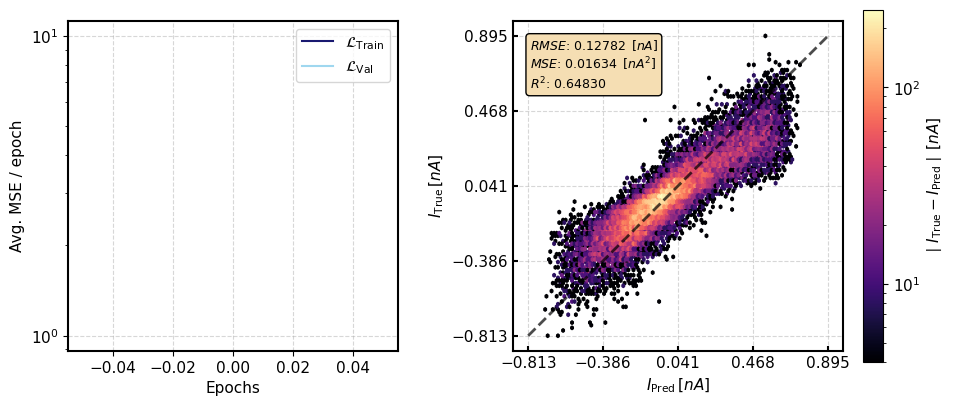

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils import pred_vs_true  # only if you actually use it elsewhere

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 11,    # affects horizontal colorbar ticks
    "ytick.labelsize": 11,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
})

# ---------------------------
# Run model on test set
# ---------------------------
coord_model.eval()
cond_model.eval()
coord_model = coord_model.to(device)
cond_model = cond_model.to(device)

pred_params = []
y_true_l = []

with torch.no_grad():
    for v, x, y in test_loader:
        v = v.to(device, non_blocking=True, dtype=torch.float32)
        x = x.to(device, non_blocking=True, dtype=torch.float32)
        y = y.to(device, non_blocking=True, dtype=torch.float32)
        z = coord_model(x).squeeze(dim=1)
        
        preds = cond_model(torch.cat([v, z], dim=1)).detach().cpu().numpy()
        pred_params.append(preds)
        y_true_l.append(y.cpu().numpy())

# Take first parameter as prediction
y_pred_l = [params for params in pred_params]

scale = 1e0
y_pred = np.concatenate(y_pred_l, axis=0).ravel() * scale
y_true = np.concatenate(y_true_l, axis=0).ravel() * scale

# Range for diagonal and limits
lo = min(y_pred.min(), y_true.min())
hi = max(y_pred.max(), y_true.max())  # use max here, not min
print("lo, hi:", lo, hi)
plot_range = [[lo, hi], [lo, hi]]

# ---------------------------
# Create figure + axes
# ---------------------------
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

# Make both axes boxes square and same size
for a in ax:
    a.set_box_aspect(1)

# ---------------------------
# Left subplot: Losses
# ---------------------------
ax[0].plot(train_losses, c='midnightblue', zorder=5, label='$\mathcal{L}_{\mathrm{Train}}$', lw=1.5)
ax[0].plot(val_losses, c='skyblue', alpha=.8, zorder=4, label='$\mathcal{L}_{\mathrm{Val}}$', lw=1.5)
ax[0].grid(alpha=.5, ls='dashed')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Avg. MSE / epoch')
ax[0].legend()
ax[0].set_yscale('log')

for spine in ax[0].spines.values():
    spine.set_linewidth(1.5)

# ---------------------------
# Right subplot: Test set hexbin
# ---------------------------

#ax[1].set_xticks(np.linspace(lo, hi, 3))
#ax[1].set_yticks(np.linspace(lo, hi, 3))

residuals = y_pred - y_true           # or y_true - y_pred, just be consistent
abs_errors = np.abs(residuals)

"""im = ax[1].hexbin(
    y_pred,
    y_true,
    C=abs_errors,                    # values per point
    reduce_C_function=np.mean,       # aggregate: mean |error| in each bin
    gridsize=100,
    cmap="magma_r",                  # continuous colormap works well here
    # norm=LogNorm(),                # optional; linear is often easier to read
    zorder=5,
)"""

norm = LogNorm()

im = ax[1].hexbin(
    y_pred,
    y_true,
    bins=250,
    gridsize=100,
    norm=norm,
    cmap="magma",
    zorder=5,
)
ax[1].plot(
    [lo, hi],
    [lo, hi],
    linestyle='--',
    linewidth=2,
    color='k',
    alpha=0.7,
    zorder=6,
)

pad = 0.0  # or e.g. hi * 0.1
#ax[1].set_xlim(lo - pad, hi + pad)
#ax[1].set_ylim(lo - pad, hi + pad)

ticks = np.linspace(lo, hi, 5)
ax[1].set_xticks(ticks)
ax[1].set_yticks(ticks)

ax[1].set_aspect('equal', adjustable='box')

# Colorbar attached to BOTH axes (so they shrink equally),
# but made thinner/shorter so it doesn't look huge.
pos = ax[1].get_position()

# Create a custom colorbar axes with same height
cax = fig.add_axes([
    pos.x1 + 0.02,  # a bit to the right of ax[1]
    pos.y0,         # same bottom
    0.02,           # fixed width
    pos.height      # same height as ax[1] outer box
])

cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\mid I_{\mathrm{True}} - I_{\mathrm{Pred}} \mid \, [nA]$')

for spine in ax[1].spines.values():
    spine.set_linewidth(1.5)

ax[1].tick_params(direction='in', width=1.5)
ax[1].set_facecolor('w')
ax[1].grid(alpha=.5, ls='dashed')
ax[1].set_xlabel(r'$I_{\mathrm{Pred}} \, [nA]$')
ax[1].set_ylabel(r'$I_{\mathrm{True}} \, [nA]$')

# ---------------------------
# Metrics
# ---------------------------
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
R_sq = 1 - mse / np.var(y_true)  # standard R^2 definition

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2: {R_sq}')
print("y_true min/max/std:", y_true.min(), y_true.max(), y_true.std())

plot_text = (
    rf'$RMSE$: {rmse:.5f} $\, [nA]$'
    '\n'
    rf'$MSE$: {mse:.5f} $\, [nA^2]$'
    '\n'
    f'$R^2$: {R_sq:.5f}'
)

props = dict(boxstyle='round', facecolor='wheat', alpha=1)
ax[1].text(
    x=0.05,
    y=0.95,
    s=plot_text,
    transform=ax[1].transAxes,
    bbox=props,
    va='top',
    ha='left',
    zorder=6,
    fontsize=9
)
fig.subplots_adjust(wspace=0.35)
#plt.savefig('dasdsa.pdf', bbox_inches='tight')
plt.show()